# CNN do zero em PyTorch




In [1]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.transforms import ToTensor, Lambda, Compose
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import numpy as np
import time, os
from sklearn.svm import LinearSVC

%matplotlib inline


## LeNet 5

Primeiro de tudo, precisamos **implementar uma CNN**. Sim, chegou a hora de colocar em prática tudo que já sabemos sobre redes convolucionais, montando uma arquitetura completa!

A arquitetura escolhida para essa aula é a LeNet. Ela é a primeira CNN bem sucedida da história, [proposta em 1998 pelo Yann LeCun](http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf).

<img src="https://drive.google.com/uc?export=view&id=1BThCsFE8fSCe012klZmp8UpslOlzWsmK" width="800">

<img src="https://drive.google.com/uc?export=view&id=1oG_Jh8nA2Nrq8RTcIyJEOaIXXxa10Srw" width="700">

Vamos implementar blocos convolucionais incluindo todas as camadas
```python
net = nn.Sequential(
          nn.Conv2d(...),
          nn.BatchNorm2d(...),
          nn.Tanh(), # Ativação específica da LeNet
          nn.AvgPool2d(...), # Pooling específico da LeNet
      )
```

In [2]:
args = {
    'epoch_num': 150,     # Número de épocas.
    'lr': 1e-3,           # Taxa de aprendizado.
    'weight_decay': 1e-3, # Penalidade L2 (Regularização).
    'batch_size': 50,     # Tamanho do batch.
}

if torch.cuda.is_available():
    args['device'] = torch.device('cuda')
else:
    args['device'] = torch.device('cpu')

print(args['device'])

cuda


In [3]:
model = nn.Sequential(
        #entrada (b, 3, 32, 32) output (b, 6, 28, 28)
        nn.Conv2d(3, 6, kernel_size=5),
        nn.BatchNorm2d(6),
        nn.Tanh(),
        #entrada (b, 6, 28, 28) output (b, 6, 14, 14)
        nn.AvgPool2d(kernel_size=2),

        #entrada (b, 6, 14, 14) output (b, 16, 10, 10)
        nn.Conv2d(6, 16, kernel_size=5),
        nn.BatchNorm2d(16),
        nn.Tanh(),
        #entrada (b, 16, 10, 10) output (b, 16, 5, 5)
        nn.AvgPool2d(kernel_size=2),

        #entrada (b, 16, 5, 5) output (b, 120, 1, 1)
        nn.Conv2d(16, 120, kernel_size=5),
        nn.BatchNorm2d(120),
        nn.Tanh(),
        nn.Flatten(), #entrada (b, N=120*1*1)
        nn.Linear(120, 84),
        nn.Tanh(),
        #entrada (b, 84) output (b, 10)
        nn.Linear(84, 10)
        )

model = model.to(args['device'])
print(model)

Sequential(
  (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): Tanh()
  (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (4): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): Tanh()
  (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (8): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (9): BatchNorm2d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): Tanh()
  (11): Flatten(start_dim=1, end_dim=-1)
  (12): Linear(in_features=120, out_features=84, bias=True)
  (13): Tanh()
  (14): Linear(in_features=84, out_features=10, bias=True)
)


## Carregamento de Dados

Usaremos o dataset [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html), um conjunto de imagens RGB divididas em 10 categorias de objeto: avião, automóvel, pássaro, gato, veado, cachorro, sapo, cavalo, navio, caminhão. As imagens possuem $32 \times 32$ pixels.

Trata-se de um dataset de 60 mil imagens naturais (do mundo real), muito utilizado para avaliar a qualidade de modelos de aprendizado profundo.

https://pytorch.org/docs/stable/torchvision/datasets.html#cifar

In [4]:
data_transform = transforms.Compose([
                                     transforms.Resize(32),
                                     transforms.ToTensor(),])

train_set = datasets.CIFAR10('.',
                      train=True,
                      transform=data_transform,
                      download=True)

test_set = datasets.CIFAR10('.',
                      train=False,
                      transform=data_transform,
                      download=False)

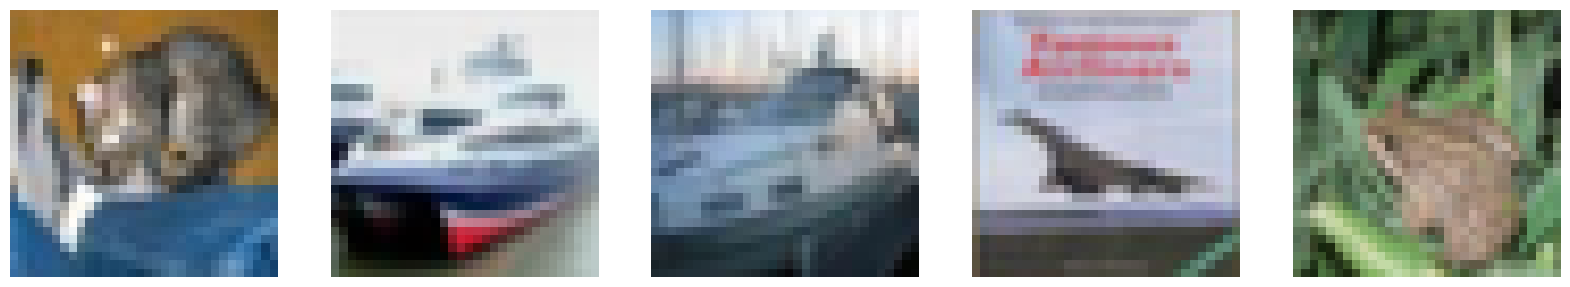

In [5]:
fig, axs = plt.subplots(1,5, figsize=(20, 12))
for i in range(5):
  data, label = test_set[i]
  axs[i].imshow(data.permute((1,2,0)))
  axs[i].axis('off')

In [6]:
train_loader = DataLoader(train_set,
                          batch_size=args['batch_size'],
                          shuffle=True)

test_loader = DataLoader(test_set,
                          batch_size=args['batch_size'],
                          shuffle=True)

O primeiro passo do treinamento do zero é definir os algoritmos que serão utilizados no processo de treinamento. Eles são:

* **Função de perda**, que vai avaliar a qualidade da performance da rede a cada passo de treinamento;
* **Otimizador**, que a partir da função de perda vai definir a melhor forma de atualizar os pesos.

In [7]:
criterion = nn.CrossEntropyLoss().to(args['device'])
optimizer = optim.Adam(model.parameters(), lr=args['lr'], weight_decay=args['weight_decay'])

Relembrando o passo a passo do fluxo de treinamento:

* Iterar nas épocas
* Iterar nos batches
* Cast dos dados no dispositivo de hardware
* Forward na rede e cálculo da loss
* Zerar o gradiente do otimizador
* Cálculo do gradiente e atualização dos pesos

Para acompanhar a convergência do seu modelo (e garantir que tudo foi feito certinho), ao final de cada época podemos imprimir a média e o desvio padrão das perdas de cada iteração.

In [8]:
def train(train_loader, model, epoch):
  model.train()

  start = time.time()

  epoch_loss  = []
  pred_list, rotulo_list = [], []
  for batch in train_loader:

    dado, rotulo = batch

    dado = dado.to(args['device'])
    rotulo = rotulo.to(args['device'])

    # Forward
    ypred = model(dado)
    loss = criterion(ypred, rotulo)
    epoch_loss.append(loss.detach().cpu().item())

    _, pred = torch.max(ypred, axis=1)
    pred_list.append(pred.cpu().numpy())
    rotulo_list.append(rotulo.cpu().numpy())

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  epoch_loss = np.asarray(epoch_loss)
  pred_list  = np.asarray(pred_list).ravel()
  rotulo_list  = np.asarray(rotulo_list).ravel()

  acc = accuracy_score(pred_list, rotulo_list)

  end = time.time()
  print('#################### Train ####################')
  print('Epoch %d, Loss: %.4f +/- %.4f, Acc: %.2f, Time: %.2f' % (epoch, epoch_loss.mean(), epoch_loss.std(), acc*100, end-start))

  return epoch_loss.mean()


### Validação

Para essa etapa, o PyTorch oferece dois artifícios:
* ```model.eval()```: Impacta no *forward* da rede, informando as camadas caso seu comportamento mude entre fluxos (ex: dropout).
* ```with torch.no_grad()```: Gerenciador de contexto que desabilita o cálculo e armazenamento de gradientes (economia de tempo e memória). Todo o código de validação deve ser executado dentro desse contexto.

Exemplo de código para validação

```python
net.eval()
with torch.no_grad():
  for batch in test_loader:
      # Código de validação
```

Existe o equivalente ao ```model.eval()``` para explicitar que a sua rede deve estar em modo de treino, é o ```model.train()```. Apesar de ser o padrão dos modelos, é boa prática definir também o modo de treinamento.

In [9]:
def validate(test_loader, model, epoch):
  model.eval()

  start = time.time()

  epoch_loss  = []
  pred_list, rotulo_list = [], []
  with torch.no_grad():
    for batch in test_loader:

      dado, rotulo = batch

      dado = dado.to(args['device'])
      rotulo = rotulo.to(args['device'])

      # Forward
      ypred = model(dado)
      loss = criterion(ypred, rotulo)
      epoch_loss.append(loss.detach().cpu().data)

      _, pred = torch.max(ypred, axis=1)
      pred_list.append(pred.cpu().numpy())
      rotulo_list.append(rotulo.cpu().numpy())

  epoch_loss = np.asarray(epoch_loss)
  pred_list  = np.asarray(pred_list).ravel()
  rotulo_list  = np.asarray(rotulo_list).ravel()

  acc = accuracy_score(pred_list, rotulo_list)

  end = time.time()
  print('********** Validate **********')
  print('Epoch %d, Loss: %.4f +/- %.4f, Acc: %.2f, Time: %.2f\n' % (epoch, epoch_loss.mean(), epoch_loss.std(), acc*100, end-start))

  return epoch_loss.mean()


In [13]:
train_losses, val_losses = [], []
for epoch in range(args['epoch_num']):

  train_losses.append(train(train_loader, model, epoch))

  val_losses.append(validate(test_loader, model, epoch))

#################### Train ####################
Epoch 0, Loss: 1.4609 +/- 0.1462, Acc: 47.93, Time: 10.62
********** Validate **********
Epoch 0, Loss: 1.4788 +/- 0.1534, Acc: 48.22, Time: 1.65

#################### Train ####################
Epoch 1, Loss: 1.3735 +/- 0.1453, Acc: 51.15, Time: 10.39
********** Validate **********
Epoch 1, Loss: 1.4857 +/- 0.1675, Acc: 46.77, Time: 1.69

#################### Train ####################
Epoch 2, Loss: 1.3037 +/- 0.1505, Acc: 53.53, Time: 10.39
********** Validate **********
Epoch 2, Loss: 1.2649 +/- 0.1303, Acc: 54.73, Time: 1.78

#################### Train ####################
Epoch 3, Loss: 1.2511 +/- 0.1536, Acc: 55.61, Time: 10.26
********** Validate **********
Epoch 3, Loss: 1.3281 +/- 0.1611, Acc: 52.71, Time: 1.75

#################### Train ####################
Epoch 4, Loss: 1.2135 +/- 0.1471, Acc: 57.14, Time: 10.29
********** Validate **********
Epoch 4, Loss: 1.2453 +/- 0.1421, Acc: 55.82, Time: 3.32

#################### Trai

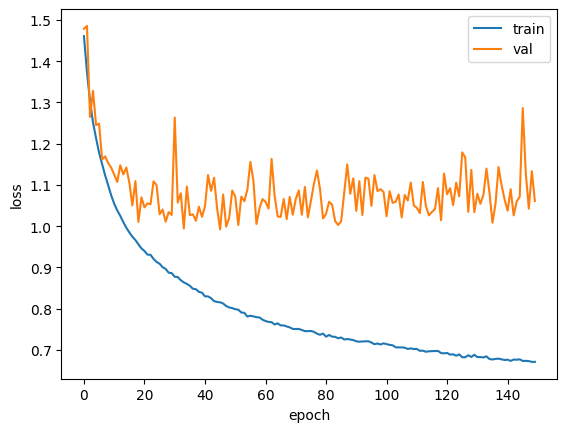

In [14]:
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

## Extração de características

In [15]:
data_transform = transforms.Compose([
                transforms.Resize(224),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                    std=[0.229, 0.224, 0.225]) #normalizando igual ImageNet
                  ])

train_set = datasets.CIFAR10('.',
                      train=True,
                      transform = data_transform, # transformação composta
                      download=True)

test_set = datasets.CIFAR10('.',
                      train=False,
                      transform= data_transform, # transformação composta
                      download=False)

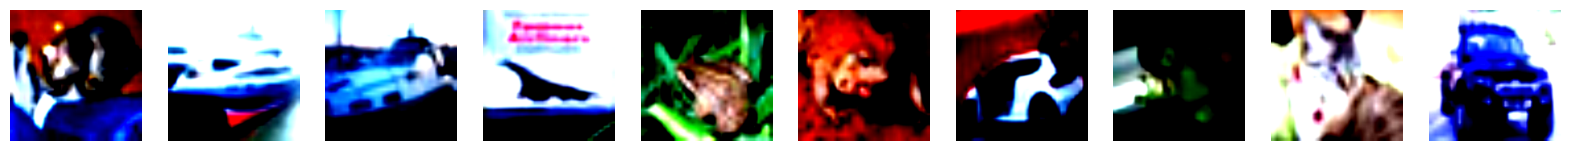

In [16]:
fig, axs = plt.subplots(1,10, figsize=(20, 2))
for i in range(10):
  data, label = test_set[i]
  axs[i].imshow(data.permute((1,2,0)))
  axs[i].axis('off')

In [10]:
model = models.vgg16_bn(pretrained=True).to(args['device'])
print(model)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

Através da função ```net.children()``` conseguimos acessar individualmente os módulos implementados na rede.

In [11]:
print(list(model.named_children())[-1])

('classifier', Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
))


In [12]:
list(model.children())[-1][:-3]

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
)

Podemos redefinir a rede com todos os módulos originais **exceto o último**, responsável pela classificação das características aprendidas pelas camadas anteriores.

In [13]:
model.classifier = nn.Sequential(list(model.children())[-1][:-3]).to(args['device'])
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

Nesse passo realizamos o mesmo fluxo da função de validação que implementamos anteriormente. Dessa vez não precisamos calcular a predição final, apenas armazenar as saídas da rede.

In [43]:
def extrai_caracteristicas(model, loader):

  model.eval()

  feat_list, rotulo_list = [], []
  with torch.no_grad():
    for k, batch in enumerate(loader):
      print('\r--{0}/{1}--'.format(k, len(loader)), end='', flush=True)

      dado, rotulo = batch

      # Cast do dado na GPU
      dado = dado.to(args['device'])
      rotulo = rotulo.to(args['device'])

      # Extração
      caracteristica = model(dado)
      feat_list.append(caracteristica.detach().cpu().numpy())
      rotulo_list.append(rotulo.detach().cpu().numpy())

  feat_list    = np.asarray(feat_list)
  feat_list    = np.reshape(feat_list, (feat_list.shape[0]*feat_list.shape[1], feat_list.shape[2]))

  rotulo_list  = np.asarray(rotulo_list).ravel()

  return feat_list, rotulo_list


In [44]:
print('Load train')
train_X, train_Y = extrai_caracteristicas(model, train_loader)
print('\nLoad test')
test_X,  test_Y  = extrai_caracteristicas(model, test_loader)

Load train
--999/1000--
Load test
--199/200--

### Treinando um modelo de classificação (SVM)
Documentação: https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html

Modelos de classificação no pacote ```scikit-learn``` seguem o seguinte padrão de uso:
```python
# Definição do classificador
clf = LinearSVC()
#Treinando
clf.fit(X, y)
# Usando no teste
pred = clf.predict(Xt)
```

In [ ]:
clf = LinearSVC()
clf.fit(train_X, train_Y)

pred = clf.predict(test_X)
acc = accuracy_score(test_Y, pred)
print('Acc: %.2f' % (acc*100))



---


### Fine-Tuning

O objetivo aqui é aproveitar o valor de um modelo bem treinado e sua capacidade de generalizar pra dados que nunca viu antes.

Lembre-se que o aprendizado é hierárquico, ou seja, camadas iniciais (em vermelho na imagem) aprendem características de baixo nível (bordas, quinas, etc.) que podem ser aproveitadas para múltiplos datasets. **Adaptamos então camadas mais semânticas** (em amarelo na imagem), que aprendem características mais específicas do dataset de treino.

Aqui seguiremos dois passos:
* Substituir a camada de classificação da rede original;
* "Congelar" camadas iniciais da rede, para preservar seus pesos;
* Definir múltiplas taxas de aprendizado para treinar as camadas finais.

<img src="https://drive.google.com/uc?export=view&id=1BHzTprOsXunB7xmKZ7amcScfh2MRSqO1" alt="drawing" width="400"/>

In [19]:
model = models.vgg16_bn(pretrained=True).to(args['device'])

list(model.children())[-1]
input = list(model.children())[-1][-1].in_features
print(list(model.children())[-1][-1])
print(input)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Linear(in_features=4096, out_features=1000, bias=True)
4096


In [20]:
print(list(model.classifier.children()))

[Linear(in_features=25088, out_features=4096, bias=True), ReLU(inplace=True), Dropout(p=0.5, inplace=False), Linear(in_features=4096, out_features=4096, bias=True), ReLU(inplace=True), Dropout(p=0.5, inplace=False), Linear(in_features=4096, out_features=1000, bias=True)]


In [21]:
new_classifier =list(model.classifier.children())[:-1]
new_classifier.append(nn.Linear(input, 10))

model.classifier = nn.Sequential(*new_classifier).to(args['device'])
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

Para "congelar" as camadas iniciais basta alterar o atributo ```requires_grad```, definindo-o como ```False``` para parâmetros que não queremos treinar. Podemos iterar nos parâmetros da rede através da função ```net.named_parameters()```.

Para definir múltiplas taxas de aprendizados no otimizador, podemos consultar a documentação do pacote ```optim```:<br>
https://pytorch.org/docs/stable/optim.html

Podemos definir uma lista de dicionários para cada módulo que desejamos treinar.
```python
optim.Adam([
            {'params': model.base.parameters()},
            {'params': model.classifier.parameters(), 'lr': 1e-3}
          ], lr=0)
```

In [22]:
optimizer = optim.Adam([
            {'params': model.features.parameters(), 'lr':args['lr']*0.2, 'weight_decay': args['weight_decay']*0.2},
            {'params': model.classifier.parameters(), 'lr': args['lr'], 'weight_decay': args['weight_decay']}
        ], lr=0)

In [23]:
criterion = nn.CrossEntropyLoss().to(args['device'])

In [24]:
def train(train_loader, model, epoch):
  model.train()

  start = time.time()

  epoch_loss  = []
  pred_list, rotulo_list = [], []
  for k, batch in enumerate(train_loader):
    print('\r--{0}/{1}--'.format(k, len(train_loader)), end='', flush=True)
    dado, rotulo = batch

    # Cast do dado na GPU
    dado = dado.to(args['device'])
    rotulo = rotulo.to(args['device'])

    # Forward
    ypred = model(dado)
    # print(ypred.size(), rotulo.size())
    loss = criterion(ypred, rotulo)
    # print(loss.size())
    epoch_loss.append(loss.cpu().data)

    _, pred = torch.max(ypred, axis=1)
    pred_list.append(pred.cpu().numpy())
    rotulo_list.append(rotulo.cpu().numpy())

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  epoch_loss = np.asarray(epoch_loss)
  pred_list  = np.asarray(pred_list).ravel()
  rotulo_list  = np.asarray(rotulo_list).ravel()

  acc = accuracy_score(pred_list, rotulo_list)

  end = time.time()
  print('\n#################### Train ####################')
  print('Epoch %d, Loss: %.4f +/- %.4f, Acc: %.2f, Time: %.2f' % (epoch, epoch_loss.mean(), epoch_loss.std(), acc*100, end-start))

  return epoch_loss.mean()


In [25]:
def validate(test_loader, model, epoch):
  model.eval()

  start = time.time()

  epoch_loss  = []
  pred_list, rotulo_list = [], []
  with torch.no_grad():
    for k, batch in enumerate(test_loader):

      print('\r--{0}/{1}--'.format(k, len(test_loader)), end='', flush=True)
      dado, rotulo = batch

      # Cast do dado na GPU
      dado = dado.to(args['device'])
      rotulo = rotulo.to(args['device'])

      # Forward
      ypred = model(dado)
      loss = criterion(ypred, rotulo)
      epoch_loss.append(loss.cpu().data)

      _, pred = torch.max(ypred, axis=1)
      pred_list.append(pred.cpu().numpy())
      rotulo_list.append(rotulo.cpu().numpy())

  epoch_loss = np.asarray(epoch_loss)
  pred_list  = np.asarray(pred_list).ravel()
  rotulo_list  = np.asarray(rotulo_list).ravel()

  acc = accuracy_score(pred_list, rotulo_list)

  end = time.time()
  print('\n********** Validate **********')
  print('Epoch %d, Loss: %.4f +/- %.4f, Acc: %.2f, Time: %.2f\n' % (epoch, epoch_loss.mean(), epoch_loss.std(), acc*100, end-start))

  return epoch_loss.mean()


In [26]:
train_losses, val_losses = [], []
for epoch in range(10):

  # Train
  train_losses.append(train(train_loader, model, epoch))

  # Validate
  val_losses.append(validate(test_loader, model, epoch))

--999/1000--
#################### Train ####################
Epoch 0, Loss: 0.8254 +/- 0.3442, Acc: 74.85, Time: 84.08
--199/200--
********** Validate **********
Epoch 0, Loss: 0.5409 +/- 0.1645, Acc: 84.00, Time: 7.23

--999/1000--
#################### Train ####################
Epoch 1, Loss: 0.4815 +/- 0.1593, Acc: 86.10, Time: 83.85
--199/200--
********** Validate **********
Epoch 1, Loss: 0.4493 +/- 0.1720, Acc: 86.72, Time: 4.37

--999/1000--
#################### Train ####################
Epoch 2, Loss: 0.3617 +/- 0.1464, Acc: 89.78, Time: 83.12
--199/200--
********** Validate **********
Epoch 2, Loss: 0.5093 +/- 0.1883, Acc: 86.02, Time: 4.69

--999/1000--
#################### Train ####################
Epoch 3, Loss: 0.5312 +/- 0.5045, Acc: 87.07, Time: 83.09
--199/200--
********** Validate **********
Epoch 3, Loss: 0.4337 +/- 0.1714, Acc: 87.97, Time: 4.59

--999/1000--
#################### Train ####################
Epoch 4, Loss: 0.7205 +/- 1.5537, Acc: 86.35, Time: 83.06
-

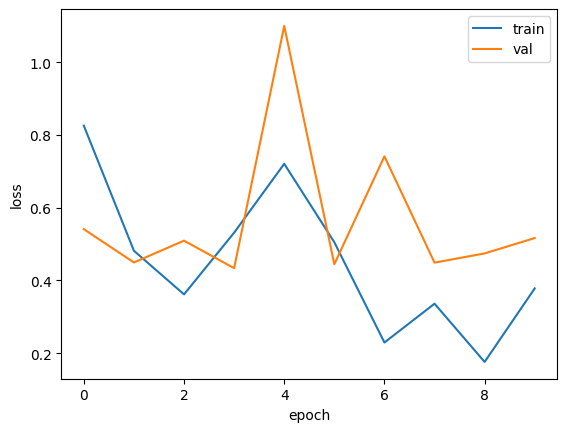

In [27]:
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()